Using device: cuda
Epoch 50, Loss: -0.47981345653533936
Epoch 100, Loss: -1.8741058111190796
Epoch 150, Loss: -1.054834246635437
Epoch 200, Loss: -0.9533730745315552
Epoch 250, Loss: -1.4627896547317505
Epoch 300, Loss: -1.684557318687439
Epoch 350, Loss: -1.41396963596344
Epoch 400, Loss: -1.9575908184051514
Epoch 450, Loss: -2.46004056930542
Epoch 500, Loss: -1.8127639293670654
Final samples shape: (200000, 6)
Final data_tensor shape: torch.Size([70000, 7])
Generated 200000 valid samples.


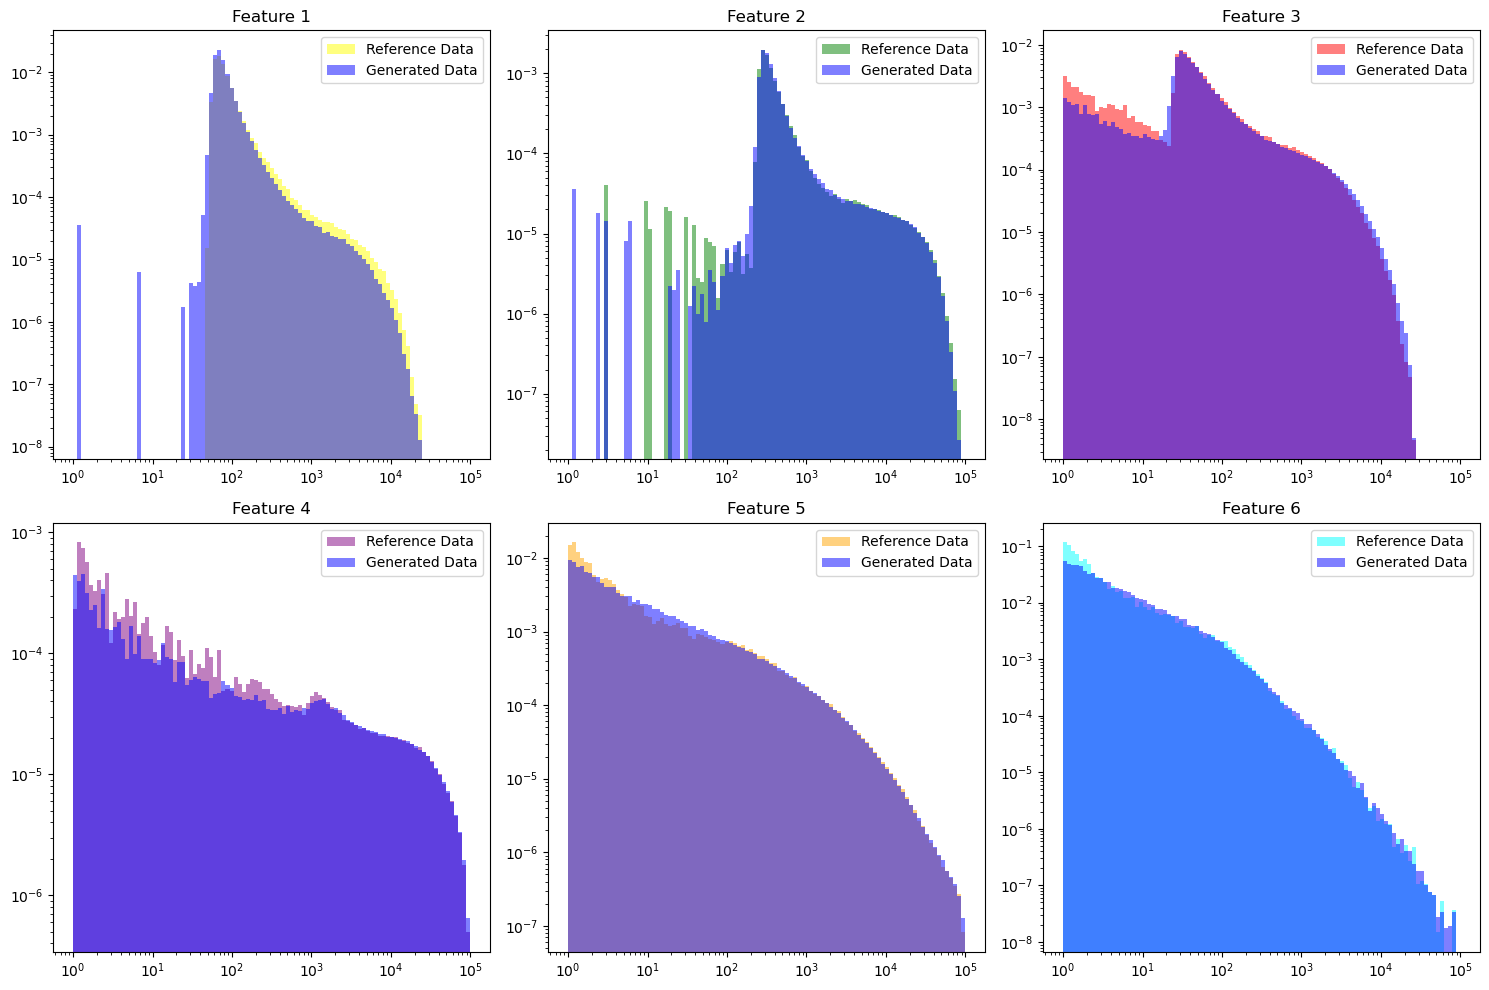

Final real data shape: (70000, 6)
Final gen shape: (70000, 6)
Epoch number 0/24
----------
train Loss: 0.6880 Acc: 0.5340
val Loss: 0.6853 Acc: 0.5409
Epoch number 1/24
----------
train Loss: 0.6856 Acc: 0.5392
val Loss: 0.6838 Acc: 0.5446
Epoch number 2/24
----------
train Loss: 0.6848 Acc: 0.5414
val Loss: 0.6822 Acc: 0.5455
Epoch number 3/24
----------
train Loss: 0.6836 Acc: 0.5438
val Loss: 0.6817 Acc: 0.5432
Epoch number 4/24
----------
train Loss: 0.6827 Acc: 0.5436
val Loss: 0.6808 Acc: 0.5489
Epoch number 5/24
----------
train Loss: 0.6820 Acc: 0.5451
val Loss: 0.6816 Acc: 0.5447
Epoch number 6/24
----------
train Loss: 0.6812 Acc: 0.5483
val Loss: 0.6801 Acc: 0.5478
Epoch number 7/24
----------
train Loss: 0.6812 Acc: 0.5504
val Loss: 0.6797 Acc: 0.5455
Epoch number 8/24
----------
train Loss: 0.6806 Acc: 0.5490
val Loss: 0.6792 Acc: 0.5454
Epoch number 9/24
----------
train Loss: 0.6804 Acc: 0.5491
val Loss: 0.6788 Acc: 0.5476
Epoch number 10/24
----------
train Loss: 0.6798

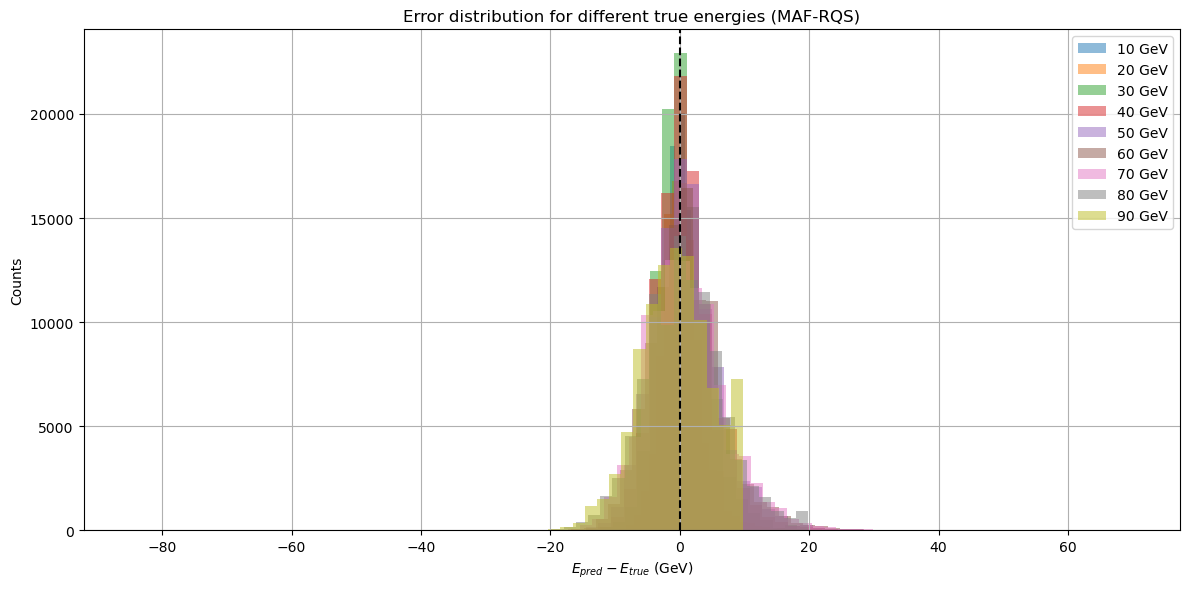

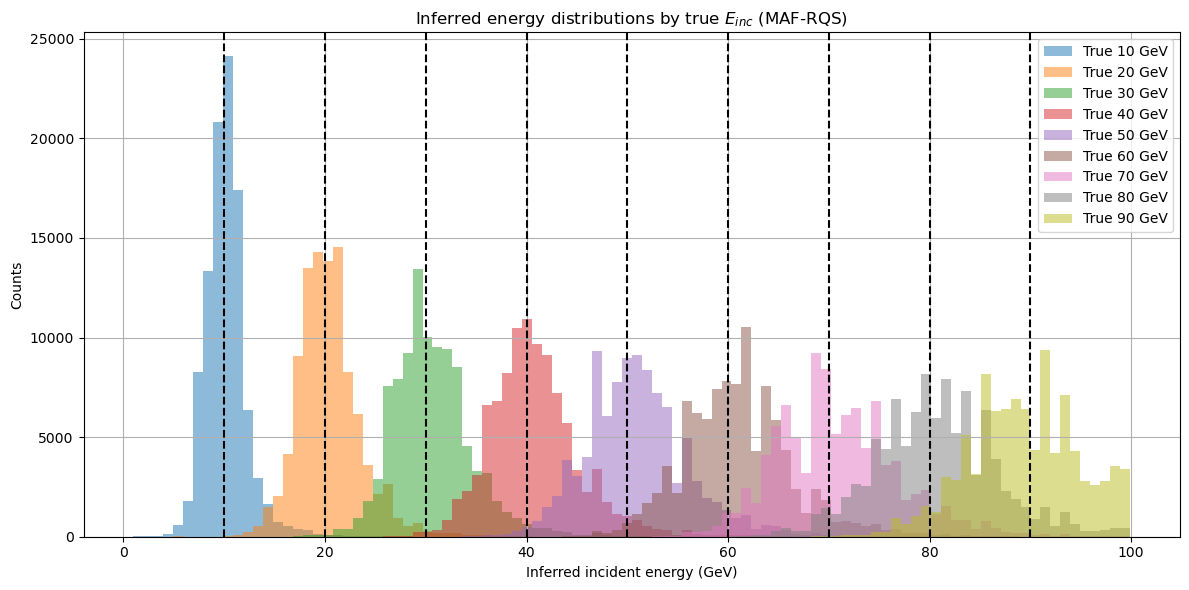


=== Per-energy regression summary ===
E_true [GeV]        N   Bias [GeV]  MAE [GeV]  RMSE [GeV]  Std [GeV]  68% width [GeV]  Sat. frac
        10    99988        0.157      1.479       2.118      2.113            3.168      0.01%
        20   100000        0.382      2.344       3.225      3.202            5.247      0.00%
        30   100000        0.592      2.986       4.041      3.998            7.029      0.00%
        40   100000        0.774      3.399       4.688      4.624            7.920      0.00%
        50    99998        0.957      3.940       5.325      5.238            9.306      0.00%
        60    99992        1.012      4.269       5.714      5.624            9.999      0.01%
        70    99987        0.927      4.759       6.229      6.159           11.484      0.01%
        80    99867        0.682      4.741       6.164      6.126           11.484      0.13%
        90    99109       -0.724      4.454       5.544      5.497           11.088      0.89%

=== Glob

In [1]:
import numpy as np  
import h5py
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from nflows.flows.base import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedPiecewiseRationalQuadraticAutoregressiveTransform
from nflows.transforms.permutations import ReversePermutation
import time
import torch.nn as nn
import torch.optim as optim
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ALPHA = 1e-6

def logit(x):
    return torch.log(x / (1.0 - x))

def logit_trafo(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x, min=1e-6, max=1 - 1e-6)
    return logit(local_x)

def inverse_logit(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

start_time = time.time()

results_dir = "MAF_RQS_results"  # CHANGED
os.makedirs(results_dir, exist_ok=True)  # CHANGED

path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data + 'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

data = np.hstack((energy.reshape(-1, 1), E_layers))

data[np.isinf(data)] = np.nan
valid_mask = ~np.isnan(data).any(axis=1)
data = data[valid_mask]

data_tensor = torch.tensor(data, dtype=torch.float32).to(device)

data_max = data_tensor.max(dim=0).values
data_tensor = data_tensor / data_max
data_tensor = logit_trafo(data_tensor)

if torch.isnan(data_tensor).any() or torch.isinf(data_tensor).any():
    raise ValueError("Data tensor contains NaN or Inf values after transformations.")

mask = ~torch.isnan(data_tensor).any(dim=1) & ~torch.isinf(data_tensor).any(dim=1)
data_tensor = data_tensor[mask]

data_mean = data_tensor.mean(dim=0)
data_std = data_tensor.std(dim=0)
data_tensor = (data_tensor - data_mean) / data_std

context_feature = data_tensor[:, 0].unsqueeze(1)
input_features = data_tensor[:, 1:]

num_layers = 5
base_distribution = StandardNormal(shape=[input_features.shape[1]])
transforms = []

for _ in range(num_layers):
    transforms.append(ReversePermutation(features=input_features.shape[1]))
    transforms.append(MaskedPiecewiseRationalQuadraticAutoregressiveTransform(
        features=input_features.shape[1],
        hidden_features=64,
        context_features=1,
        num_bins=10,
        tails='linear',
        tail_bound=15.0
    ))

transform = CompositeTransform(transforms)
flow = Flow(transform, base_distribution).to(device)

optimizer = torch.optim.Adam(flow.parameters(), lr=1e-4)
num_epochs = 500
batch_size = 256
best_loss = float('inf')

best_model_path = os.path.join(results_dir, "best_flow_model_maf-rqs.pth")  # CHANGED
for epoch in range(num_epochs):
    idx = torch.randperm(len(data_tensor))
    data_tensor = data_tensor[idx]

    context_feature = data_tensor[:, 0].unsqueeze(1)
    input_features = data_tensor[:, 1:]

    for i in range(0, len(input_features), batch_size):
        batch_inputs = input_features[i:i + batch_size]
        batch_context = context_feature[i:i + batch_size]

        optimizer.zero_grad()
        loss = -flow.log_prob(inputs=batch_inputs, context=batch_context).mean()

        if not torch.isnan(loss) and not torch.isinf(loss):
            loss.backward()
            optimizer.step()
            if loss.item() < best_loss:  # CHANGED
                best_loss = loss.item()  # CHANGED
                torch.save(flow.state_dict(), best_model_path)  # CHANGED

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item()}")

flow.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))  # CHANGED

import torch.nn.functional as F

n_samples = 200000
batch_size = 1000
all_samples = []

Einc_gen = torch.rand((n_samples,1)).to(device) * 99 + 1
Einc_gen = Einc_gen / data_max[0]
Einc_gen = logit_trafo(Einc_gen)
Einc_gen = (Einc_gen - data_mean[0]) / data_std[0]

with torch.no_grad():
    for i in range(0, n_samples, batch_size):
        current_batch_size = min(batch_size, n_samples - i)
        batch_context = Einc_gen[i:i+batch_size]
        samples_batch = flow.sample(1, context=batch_context).detach().cpu()
        all_samples.append(samples_batch)

samples = torch.cat(all_samples, dim=0)
samples = samples * data_std[1:].cpu() + data_mean[1:].cpu()
samples = inverse_logit(samples)
samples = samples * data_max[1:].cpu()
samples = samples.squeeze().numpy()

print(f"Final samples shape: {samples.shape}")
print(f"Final data_tensor shape: {data_tensor.shape}")
print(f"Generated {len(samples)} valid samples.")

num_features = data.shape[1] - 1
fig_hist, axs = plt.subplots(2, 3, figsize=(15, 10))  # CHANGED
axs = axs.flatten()

colors = ['yellow', 'green', 'red', 'purple', 'orange', 'cyan']

for i in range(num_features):
    bins = np.logspace(0, 5, 100)
    counts, bin_edges, _ = axs[i].hist(
        data[:, i + 1],
        bins=bins,
        alpha=0.5,
        label="Reference Data",
        color=colors[i % len(colors)],
        density=True,
        log=True
    )
    axs[i].hist(
        samples[:, i],
        bins=bin_edges,
        alpha=0.5,
        label="Generated Data",
        color='blue',
        density=True,
        log=True
    )
    axs[i].set_xscale('log')
    axs[i].legend()
    axs[i].set_title(f"Feature {i + 1}")

for j in range(len(axs)):
    if j >= num_features:
        axs[j].axis('off')

plt.tight_layout()
fig_hist.savefig(os.path.join(results_dir, "maf-rqs_feature_histograms.png"), dpi=300, bbox_inches='tight')  # CHANGED
plt.show()

from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import copy

real_data = data[:, 1:]
generated_data = samples

smallest_size = min(len(real_data), len(generated_data))

real_indices = np.random.choice(len(real_data), smallest_size, replace=False)
generated_indices = np.random.choice(len(generated_data), smallest_size, replace=False)

real_data = real_data[real_indices]
generated_data = generated_data[generated_indices]

print(f"Final real data shape: {real_data.shape}")
print(f"Final gen shape: {generated_data.shape}")

real_labels = np.ones(len(real_data))  
maf_labels = np.zeros(len(generated_data))

combined_data = np.vstack((real_data, generated_data))
combined_labels = np.hstack((real_labels, maf_labels))

X_train, X_test, y_train, y_test = train_test_split(
    combined_data, combined_labels, test_size=0.2, random_state=42, stratify=combined_labels
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    probs = torch.sigmoid(outputs)
                    preds = torch.round(probs)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print('highest validation accuracy: {:4f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloaders):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        with torch.no_grad():
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            preds = torch.round(probs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    print('Accuracy: {:.4f}, AUC (area under roc curve): {:.4f}'.format(acc, auc))
    return acc, auc

train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)
}

input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
clf_acc, clf_auc = evaluate_model(model, dataloaders)  # CHANGED

end_time = time.time()
elapsed_time = end_time - start_time
hours, rem = divmod(elapsed_time, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total time taken: {int(hours)}h {int(minutes)}m {seconds:.2f}s")


# REGRESSION EVALUATION 
import os
import time
import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt

eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
energy_values = list(range(10, 91, 10))

Emin = 1.0
Emax = 120.0
num_scan_points = 1000
batch_size = 10000

errors_by_energy = {}
inferred_by_energy = {}
sat_frac_by_energy = {}

def logit_reg(x):
    return torch.log(x / (1.0 - x))

def logit_trafo_reg(x):
    local_x = torch.clamp(ALPHA + (1. - 2. * ALPHA) * x,
                          min=1e-6, max=1 - 1e-6)
    return logit_reg(local_x)

def inverse_logit_reg(x):
    return (torch.sigmoid(x) - ALPHA) / (1. - 2.*ALPHA)

def load_and_preprocess_test_file(filepath, data_mean_reg, data_std_reg, data_max_reg, device):
    with h5py.File(filepath, 'r') as f:
        energy = f['energy'][:]
        layers = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

    data = np.hstack((energy.reshape(-1, 1), E_layers))
    data[np.isinf(data)] = np.nan
    data = data[~np.isnan(data).any(axis=1)]

    x = torch.tensor(data, dtype=torch.float32, device=device)
    x = x / data_max_reg
    x = logit_trafo_reg(x)
    x = (x - data_mean_reg) / data_std_reg

    return x[:, 1:]

def infer_incident_energy(flow, layer_tensor,
                          data_mean_reg, data_std_reg, data_max_reg,
                          num_scan_points=1000, Emin=1.0, Emax=120.0,
                          batch_size=10000):

    device = layer_tensor.device
    n_samples = layer_tensor.shape[0]

    Emax_eff = float(data_max_reg[0].item()) * 0.999
    E_candidates = torch.linspace(Emin, Emax_eff, num_scan_points, device=device).view(-1, 1)

    E_norm  = E_candidates / data_max_reg[0]
    E_logit = logit_trafo_reg(E_norm)
    E_std   = (E_logit - data_mean_reg[0]) / data_std_reg[0]

    E_context = E_std.view(1, -1, 1).repeat(n_samples, 1, 1)
    inputs    = layer_tensor.unsqueeze(1).repeat(1, num_scan_points, 1)

    flat_inputs  = inputs.view(-1, inputs.shape[-1])
    flat_context = E_context.view(-1, 1)

    log_probs_list = []
    flow.eval()
    with torch.no_grad():
        for i in range(0, flat_inputs.shape[0], batch_size):
            logp = flow.log_prob(flat_inputs[i:i+batch_size],
                                 context=flat_context[i:i+batch_size])
            log_probs_list.append(logp)

    log_probs = torch.cat(log_probs_list).view(n_samples, num_scan_points)
    max_indices = log_probs.argmax(dim=1)

    inferred_E = E_candidates[max_indices].squeeze(1).cpu().numpy()
    return inferred_E, max_indices.cpu().numpy()

data_mean_reg = data_mean.to(device)
data_std_reg  = data_std.to(device)
data_max_reg  = data_max.to(device)
flow = flow.to(device)

print("data_max_reg[0] =", float(data_max_reg[0].item()))
Emax_eff = float(data_max_reg[0].item()) * 0.999

reg_start_time = time.time()

for E_true in energy_values:
    t0 = time.time()

    file_path = os.path.join(eval_folder, f'piplus_{E_true}GeV.hdf5')
    layer_tensor = load_and_preprocess_test_file(
        file_path, data_mean_reg, data_std_reg, data_max_reg, device
    )

    inferred, max_idx = infer_incident_energy(
        flow, layer_tensor,
        data_mean_reg, data_std_reg, data_max_reg,
        num_scan_points=num_scan_points, Emin=Emin, Emax=Emax, batch_size=batch_size
    )

    sat = (max_idx == 0) | (max_idx == (num_scan_points - 1))
    sat_frac = float(sat.mean())
    sat_frac_by_energy[E_true] = sat_frac

    inferred_clean = inferred[~sat]
    if len(inferred_clean) == 0:
        inferred_clean = inferred
        print("  WARNING: all events saturated; keeping unfiltered inferred values for this energy.")

    error = inferred_clean - E_true
    errors_by_energy[E_true] = error
    inferred_by_energy[E_true] = inferred_clean

    print(f"E_inc={E_true} GeV: mean error = {np.mean(error):.2f}, std = {np.std(error):.2f}, "
          f"sat = {sat_frac:.2%}, time = {time.time() - t0:.2f}s")

    counts, bin_edges = np.histogram(inferred_clean, bins=100, range=(Emin, Emax))
    bin_idx = np.digitize([E_true], bin_edges)[0] - 1
    bin_idx = max(0, min(bin_idx, len(counts) - 1))

    ratio_true_bin = counts[bin_idx] / counts.sum() if counts.sum() > 0 else 0.0
    print(f"  Bin fraction at true energy: {ratio_true_bin:.2%}")

    max_count = counts.max() if counts.size > 0 else 0
    half_max = max_count / 2 if max_count > 0 else 0
    above_half = np.where(counts >= half_max)[0] if max_count > 0 else np.array([])

    if len(above_half) > 0:
        fwhm = bin_edges[above_half[-1] + 1] - bin_edges[above_half[0]]
    else:
        fwhm = 0.0

    print(f"  FWHM: {fwhm:.2f} GeV")

reg_end_time = time.time()
reg_elapsed = reg_end_time - reg_start_time
h, rem = divmod(reg_elapsed, 3600)
m, s = divmod(rem, 60)
print(f"\nTotal regression time: {int(h)}h {int(m)}m {s:.2f}s")

fig_err = plt.figure(figsize=(12, 6))  # CHANGED
for E_true, error in errors_by_energy.items():
    plt.hist(error, bins=50, alpha=0.5, label=f"{E_true} GeV")
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("$E_{pred} - E_{true}$ (GeV)")
plt.ylabel("Counts")
plt.title("Error distribution for different true energies (MAF-RQS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
fig_err.savefig(os.path.join(results_dir, "maf-rqs_regression_error_distributions.png"), dpi=300, bbox_inches='tight')  # CHANGED
plt.show()

fig_inf = plt.figure(figsize=(12, 6))  # CHANGED
for E_true, inferred_clean in inferred_by_energy.items():
    plt.hist(inferred_clean, bins=100, range=(Emin, Emax_eff), alpha=0.5, label=f"True {E_true} GeV")
    plt.axvline(E_true, color='black', linestyle='--')
plt.xlabel("Inferred incident energy (GeV)")
plt.ylabel("Counts")
plt.title("Inferred energy distributions by true $E_{inc}$ (MAF-RQS)")
plt.legend()
plt.grid(True)
plt.tight_layout()
fig_inf.savefig(os.path.join(results_dir, "maf-rqs_inferred_energy_distributions.png"), dpi=300, bbox_inches='tight')  # CHANGED
plt.show()

summary_rows = []

all_errors = []
all_rel_errors = []
total_n = 0

for E_true in energy_values:
    err = np.asarray(errors_by_energy[E_true]).reshape(-1)

    n = len(err)
    total_n += n
    all_errors.append(err)

    rel_err = err / E_true
    all_rel_errors.append(rel_err)

    bias = float(np.mean(err))
    mae  = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    std  = float(np.std(err))

    q16, q50, q84 = np.quantile(err, [0.16, 0.50, 0.84])
    width68 = float(q84 - q16)

    sat = sat_frac_by_energy.get(E_true, np.nan)

    summary_rows.append({
        "E_true [GeV]": E_true,
        "N": n,
        "Bias [GeV]": bias,
        "MAE [GeV]": mae,
        "RMSE [GeV]": rmse,
        "Std [GeV]": std,
        "Median [GeV]": float(q50),
        "68% width [GeV]": width68,
        "Sat. frac": float(sat)
    })

all_errors = np.concatenate(all_errors) if len(all_errors) else np.array([])
all_rel_errors = np.concatenate(all_rel_errors) if len(all_rel_errors) else np.array([])

if len(all_errors) > 0:
    global_bias = float(np.mean(all_errors))
    global_mae  = float(np.mean(np.abs(all_errors)))
    global_rmse = float(np.sqrt(np.mean(all_errors**2)))
    global_std  = float(np.std(all_errors))

    gq16, gq50, gq84 = np.quantile(all_errors, [0.16, 0.50, 0.84])
    global_width68 = float(gq84 - gq16)

    global_rel_mae = float(np.mean(np.abs(all_rel_errors)))
    global_rel_rmse = float(np.sqrt(np.mean(all_rel_errors**2)))
else:
    global_bias = global_mae = global_rmse = global_std = np.nan
    global_width68 = global_rel_mae = global_rel_rmse = np.nan

print("\n=== Per-energy regression summary ===")
header = ["E_true [GeV]", "N", "Bias [GeV]", "MAE [GeV]", "RMSE [GeV]", "Std [GeV]", "68% width [GeV]", "Sat. frac"]
print("{:>10} {:>8} {:>12} {:>10} {:>11} {:>10} {:>16} {:>10}".format(*header))
for r in summary_rows:
    print("{:>10.0f} {:>8d} {:>12.3f} {:>10.3f} {:>11.3f} {:>10.3f} {:>16.3f} {:>10.2%}".format(
        r["E_true [GeV]"], r["N"], r["Bias [GeV]"], r["MAE [GeV]"], r["RMSE [GeV]"],
        r["Std [GeV]"], r["68% width [GeV]"], r["Sat. frac"]
    ))

print("\n=== Global regression summary (all energies pooled) ===")
print(f"Total N: {total_n}")
print(f"Bias  [GeV]: {global_bias:.3f}")
print(f"MAE   [GeV]: {global_mae:.3f}")
print(f"RMSE  [GeV]: {global_rmse:.3f}")
print(f"Std   [GeV]: {global_std:.3f}")
print(f"68% width [GeV]: {global_width68:.3f}")
print(f"Relative MAE  [%]: {100*global_rel_mae:.3f}")
print(f"Relative RMSE [%]: {100*global_rel_rmse:.3f}")

with open(os.path.join(results_dir, "maf-rqs_results_summary.txt"), "w") as f:  # CHANGED
    f.write("=== CLASSIFIER RESULTS ===\n")
    f.write(f"Accuracy: {clf_acc:.6f}\n")  # CHANGED
    f.write(f"AUC: {clf_auc:.6f}\n")  # CHANGED

    f.write("\n=== REGRESSION RESULTS ===\n")
    f.write(f"Total N: {total_n}\n")
    f.write(f"Bias [GeV]: {global_bias:.6f}\n")
    f.write(f"MAE [GeV]: {global_mae:.6f}\n")
    f.write(f"RMSE [GeV]: {global_rmse:.6f}\n")
    f.write(f"Std [GeV]: {global_std:.6f}\n")
    f.write(f"68% width [GeV]: {global_width68:.6f}\n")
    f.write(f"Relative MAE [%]: {100*global_rel_mae:.6f}\n")
    f.write(f"Relative RMSE [%]: {100*global_rel_rmse:.6f}\n\n")

    f.write("=== PER-ENERGY REGRESSION SUMMARY ===\n")
    for r in summary_rows:
        f.write(
            f"E_true={r['E_true [GeV]']:.0f} GeV | "
            f"N={r['N']} | "
            f"Bias={r['Bias [GeV]']:.6f} GeV | "
            f"MAE={r['MAE [GeV]']:.6f} GeV | "
            f"RMSE={r['RMSE [GeV]']:.6f} GeV | "
            f"Std={r['Std [GeV]']:.6f} GeV | "
            f"Median={r['Median [GeV]']:.6f} GeV | "
            f"68% width={r['68% width [GeV]']:.6f} GeV | "
            f"Sat. frac={r['Sat. frac']:.6%}\n"
        )

print(f"Saved figures and results to: {results_dir}")